# 1. P(s) slope curves

The notebook reads raw `.mcool` files located in "../raw" directory with following structure: "library_name" -> "coolers_library" for full files and "SRR******" for subsamples

Outputs:
* slope curves  -> `../data/slopes/<SRR>/<name>.parquet`
* dip/peak table -> `../data/datasets/*.parquet`

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import re
import gc
import glob
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, as_completed

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from tqdm import tqdm

import bioframe
import cooler
import cooltools
from scipy.ndimage import gaussian_filter1d

## Settings

In [2]:
RAW_ROOT     = Path("../raw")            # raw mcool files
SLOPES_ROOT  = Path("../data/slopes")    # slope curves
DATASETS_DIR = Path("../data/datasets")  # datasets

SLOPES_ROOT.mkdir(parents=True, exist_ok=True)
DATASETS_DIR.mkdir(parents=True, exist_ok=True)

AGG_PARQUET  = DATASETS_DIR / "dip_peak.parquet"
BIO_PARQUET  = DATASETS_DIR / "bio_replicates_dip_peak.parquet"
TECH_PARQUET = DATASETS_DIR / "tech_replicates_dip_peak.parquet"

RESOLUTION  = 1000

DEEP_MIN_BP =   6_000
DEEP_MAX_BP =  25_000
PEAK_MIN_BP =  40_000
PEAK_MAX_BP = 220_000

FULL_NPROC    = 10   # cores for one full-depth file
SAMPLE_NPROC  = 2    # cores inside one subsample job
MAX_WORKERS   = 13    # parallel subsample jobs

In [3]:
DATASETS = [
    ("U54-ESC4DN-DSG-DpnII-20190530-R1-T1",     "SRR13601502"),
    ("U54-ESC4DN-DSG-DpnII-20190530-R2-T1",     "SRR13601511"),
    ("U54-HFFc6-DSG-DdeI-DpnII-20190711-R1-T1", "SRR13601574"),
    ("U54-HFFc6-DSG-DdeI-DpnII-20191219-R3-T1", "SRR13601583"),
    ("U54-ESC4DN-FA-DpnII-2017524-R1-T1",       "SRR13601520"),
    ("U54-ESC4DN-FA-DpnII-2017524-R1-T2",       "SRR13601529"),
    ("U54-HFFc6-DSG-DpnII-20180319-R1-T1",      "SRR13601592"),
    ("U54-HFFc6-DSG-DpnII-20190102-R2-T1",      "SRR13601599"),
    ("HMEC",                                    "SRR1658680"),
    ("IMR90",                                   "SRR1658676"),
    ("kbm7",                                    "SRR1658708"),
    ("k562",                                    "SRR1658694"),
]

In [4]:
# biological replicates: group -> list of (sample_name, SRR)
BIO_GROUPS = {
    "ESC4DN-DSG-DpnII": [
        ("U54-ESC4DN-DSG-DpnII-20190530-R1-T1", "SRR13601502"),
        ("U54-ESC4DN-DSG-DpnII-20190530-R1-T1", "SRR13601503"),
        ("U54-ESC4DN-DSG-DpnII-20190530-R1-T1", "SRR13601504"),
        ("U54-ESC4DN-DSG-DpnII-20190530-R1-T1", "SRR13601505"),
        ("U54-ESC4DN-DSG-DpnII-20190530-R1-T1", "SRR13601506"),
        ("U54-ESC4DN-DSG-DpnII-20190530-R1-T1", "SRR13601507"),
        ("U54-ESC4DN-DSG-DpnII-20190530-R1-T1", "SRR13601508"),
        ("U54-ESC4DN-DSG-DpnII-20190530-R1-T1", "SRR13601509"),
        ("U54-ESC4DN-DSG-DpnII-20190530-R1-T1", "SRR13601510"),
        ("U54-ESC4DN-DSG-DpnII-20190530-R2-T1", "SRR13601511"),
        ("U54-ESC4DN-DSG-DpnII-20190530-R2-T1", "SRR13601512"),
        ("U54-ESC4DN-DSG-DpnII-20190530-R2-T1", "SRR13601513"),
        ("U54-ESC4DN-DSG-DpnII-20190530-R2-T1", "SRR13601514"),
        ("U54-ESC4DN-DSG-DpnII-20190530-R2-T1", "SRR13601515"),
        ("U54-ESC4DN-DSG-DpnII-20190530-R2-T1", "SRR13601516"),
        ("U54-ESC4DN-DSG-DpnII-20190530-R2-T1", "SRR13601517"),
        ("U54-ESC4DN-DSG-DpnII-20190530-R2-T1", "SRR13601518"),
        ("U54-ESC4DN-DSG-DpnII-20190530-R2-T1", "SRR13601519"),
    ],
    "HFFc6-DSG-DdeI-DpnII": [
        ("U54-HFFc6-DSG-DdeI-DpnII-20190711-R1-T1", "SRR13601574"),
        ("U54-HFFc6-DSG-DdeI-DpnII-20190711-R1-T1", "SRR13601575"),
        ("U54-HFFc6-DSG-DdeI-DpnII-20190711-R1-T1", "SRR13601576"),
        ("U54-HFFc6-DSG-DdeI-DpnII-20190711-R1-T1", "SRR13601577"),
        ("U54-HFFc6-DSG-DdeI-DpnII-20190711-R1-T1", "SRR13601578"),
        ("U54-HFFc6-DSG-DdeI-DpnII-20190711-R1-T1", "SRR13601579"),
        ("U54-HFFc6-DSG-DdeI-DpnII-20190711-R1-T1", "SRR13601580"),
        ("U54-HFFc6-DSG-DdeI-DpnII-20190711-R1-T1", "SRR13601581"),
        ("U54-HFFc6-DSG-DdeI-DpnII-20190711-R1-T1", "SRR13601582"),
        ("U54-HFFc6-DSG-DdeI-DpnII-20191219-R3-T1", "SRR13601583"),
        ("U54-HFFc6-DSG-DdeI-DpnII-20191219-R3-T1", "SRR13601584"),
        ("U54-HFFc6-DSG-DdeI-DpnII-20191219-R3-T1", "SRR13601585"),
        ("U54-HFFc6-DSG-DdeI-DpnII-20191219-R3-T1", "SRR13601586"),
        ("U54-HFFc6-DSG-DdeI-DpnII-20191219-R3-T1", "SRR13601587"),
        ("U54-HFFc6-DSG-DdeI-DpnII-20191219-R3-T1", "SRR13601588"),
        ("U54-HFFc6-DSG-DdeI-DpnII-20191219-R3-T1", "SRR13601589"),
        ("U54-HFFc6-DSG-DdeI-DpnII-20191219-R3-T1", "SRR13601590"),
        ("U54-HFFc6-DSG-DdeI-DpnII-20191219-R3-T1", "SRR14276401"),
    ],
    "HFFc6-DSG-DpnII": [
        ("U54-HFFc6-DSG-DpnII-20180319-R1-T1", "SRR13601592"),
        ("U54-HFFc6-DSG-DpnII-20180319-R1-T1", "SRR13601593"),
        ("U54-HFFc6-DSG-DpnII-20180319-R1-T1", "SRR13601594"),
        ("U54-HFFc6-DSG-DpnII-20180319-R1-T1", "SRR13601595"),
        ("U54-HFFc6-DSG-DpnII-20180319-R1-T1", "SRR13601596"),
        ("U54-HFFc6-DSG-DpnII-20180319-R1-T1", "SRR13601597"),
        ("U54-HFFc6-DSG-DpnII-20180319-R1-T1", "SRR13601598"),
        ("U54-HFFc6-DSG-DpnII-20190102-R2-T1", "SRR13601599"),
        ("U54-HFFc6-DSG-DpnII-20190102-R2-T1", "SRR13601600"),
        ("U54-HFFc6-DSG-DpnII-20190102-R2-T1", "SRR13601601"),
        ("U54-HFFc6-DSG-DpnII-20190102-R2-T1", "SRR13601602"),
        ("U54-HFFc6-DSG-DpnII-20190102-R2-T1", "SRR13601603"),
        ("U54-HFFc6-DSG-DpnII-20190102-R2-T1", "SRR13601604"),
        ("U54-HFFc6-DSG-DpnII-20190102-R2-T1", "SRR13601605"),
        ("U54-HFFc6-DSG-DpnII-20190102-R2-T1", "SRR13601606"),
    ],
    "IMR90": [
        ("IMR90", "SRR1658672"), ("IMR90", "SRR1658673"), ("IMR90", "SRR1658674"),
        ("IMR90", "SRR1658675"), ("IMR90", "SRR1658676"), ("IMR90", "SRR1658677"),
        ("IMR90", "SRR1658678"), ("IMR90", "SRR1658679"),
    ],
    "HMEC": [
        ("HMEC", "SRR1658680"), ("HMEC", "SRR1658681"), ("HMEC", "SRR1658682"),
        ("HMEC", "SRR1658683"), ("HMEC", "SRR1658684"), ("HMEC", "SRR1658685"),
    ],
    "k562": [
        ("k562", "SRR1658693"), ("k562", "SRR1658694"), ("k562", "SRR1658695"),
        ("k562", "SRR1658697"), ("k562", "SRR1658699"), ("k562", "SRR1658701"),
    ],
    "kbm7": [
        ("kbm7", "SRR1658703"), ("kbm7", "SRR1658705"), ("kbm7", "SRR1658706"),
        ("kbm7", "SRR1658707"), ("kbm7", "SRR1658708"),
    ],
}

# technical replicates are searched inside these libraries
TECH_SAMPLES = [
    "U54-ESC4DN-DSG-DpnII-20190530-R1-T1",
    "U54-ESC4DN-DSG-DpnII-20190530-R2-T1",
    "U54-HFFc6-DSG-DdeI-DpnII-20190711-R1-T1",
    "U54-HFFc6-DSG-DdeI-DpnII-20191219-R3-T1",
    "U54-HFFc6-DSG-DpnII-20180319-R1-T1",
    "U54-HFFc6-DSG-DpnII-20190102-R2-T1",
]

In [5]:
def full_mcool(sample_name, srr_name):
    '''Path to the full-depth mcool of one library.'''
    return str(RAW_ROOT / sample_name / "coolers_library" /
               f"{srr_name}.hg38.mapq_30.{RESOLUTION}.mcool")


def subsample_mcools(sample_name, srr_name):
    '''All subsample mcool files of one library, sorted by name.'''
    pattern = str(RAW_ROOT / sample_name / srr_name /
                  f"{srr_name}_*_sample*.hg38.mapq_30.{RESOLUTION}.mcool")
    return sorted(glob.glob(pattern))


def curve_path(srr_name, name):
    '''Path where the slope curve of one file is stored.'''
    folder = SLOPES_ROOT / srr_name
    folder.mkdir(parents=True, exist_ok=True)
    return folder / f"{name}.parquet"


def parse_subsample_name(path):
    '''Read depth and subsample number out of a subsample file name.'''
    match = re.search(r"_(\d+)_sample(\d+)\.", Path(path).name)
    depth = int(match.group(1))
    number = int(match.group(2))
    return depth, number

In [6]:
chromsizes = bioframe.fetch_chromsizes("hg38")
centromeres = bioframe.fetch_centromeres("hg38")
arms = bioframe.make_chromarms(chromsizes, centromeres)

first_clr = cooler.Cooler(f"{full_mcool(*DATASETS[0])}::resolutions/{RESOLUTION}")
arms = arms[arms.chrom.isin(first_clr.chromnames)].reset_index(drop=True)
del first_clr
gc.collect()

print(f"view: {len(arms)} chromosome arms")

view: 49 chromosome arms


## Slope curves

One parquet file per curve (`dist_bp`, `expected`, `slope`; the number of
contacts is kept in the file metadata). Separate files mean the workers can
write in parallel and an already computed curve is simply read back.

In [7]:
def compute_slope(mcool_path, nproc):
    '''Compute the P(s) curve and its log-log derivative for one mcool file.'''
    clr = cooler.Cooler(f"{mcool_path}::resolutions/{RESOLUTION}")

    cvd = cooltools.expected_cis(
        clr=clr, view_df=arms, clr_weight_name=None,
        smooth=True, aggregate_smoothed=True, nproc=nproc,
    )
    cvd["count.avg.smoothed"].loc[cvd["dist"] < 2] = np.nan

    curve = cvd.drop_duplicates(subset=["dist"])[["dist_bp", "count.avg.smoothed.agg"]]

    dist_bp = curve["dist_bp"].values
    expected = curve["count.avg.smoothed.agg"].values
    slope = np.gradient(np.log(expected), np.log(dist_bp))
    slope = gaussian_filter1d(slope, 1.0)

    num_contacts = int(cvd["count.sum"].sum())

    del clr, cvd
    gc.collect()
    return dist_bp, expected, slope, num_contacts


def save_curve(path, dist_bp, expected, slope, num_contacts):
    '''Write one slope curve to parquet.'''
    table = pa.table({"dist_bp": np.asarray(dist_bp, dtype="float64"),
                      "expected": np.asarray(expected, dtype="float64"),
                      "slope": np.asarray(slope, dtype="float64")})
    table = table.replace_schema_metadata({"num_contacts": str(num_contacts)})
    pq.write_table(table, path, compression="zstd")


def load_curve(path):
    '''Read one slope curve back from parquet.'''
    table = pq.read_table(path)
    metadata = table.schema.metadata or {}
    num_contacts = int(metadata.get(b"num_contacts", b"0"))
    dist_bp = table["dist_bp"].to_numpy(zero_copy_only=False)
    expected = table["expected"].to_numpy(zero_copy_only=False)
    slope = table["slope"].to_numpy(zero_copy_only=False)
    return dist_bp, expected, slope, num_contacts

In [8]:
def find_dip_and_peak(dist_bp, slope):
    '''Find the dip (minimum) and the peak (maximum) of the slope curve.'''
    dip_slope = slope[6:91].min()
    dip_bp = dist_bp[6:91][slope[6:91].argmin()]

    inside = (dist_bp > PEAK_MIN_BP) & (dist_bp < PEAK_MAX_BP)
    if inside.sum() == 0:
        peak_bp = np.nan
        peak_slope = np.nan
    else:
        peak_slope = slope[inside].max()
        peak_bp = dist_bp[inside][slope[inside].argmax()]

    return {"deep_bp": float(dip_bp),
            "deep_slope": float(dip_slope),
            "peak_bp": float(peak_bp),
            "peak_slope": float(peak_slope),
            "x_min_kb": float(dip_bp) / 1000,
            "y_min": float(dip_slope)}


def get_dip_and_peak(mcool_path, path, nproc):
    '''Return dip/peak of one file, computing and caching the curve if needed.'''
    if os.path.exists(path):
        dist_bp, expected, slope, num_contacts = load_curve(path)
    else:
        dist_bp, expected, slope, num_contacts = compute_slope(mcool_path, nproc)
        save_curve(path, dist_bp, expected, slope, num_contacts)

    result = find_dip_and_peak(dist_bp, slope)
    result["num_contacts"] = num_contacts
    return result


def run_jobs(jobs, max_workers, description):
    '''Run get_dip_and_peak on many files in parallel and collect the rows.

    Each job is a dict with keys "mcool", "path", "nproc" and "info"
    (the columns describing the file).
    '''
    rows = []
    with ProcessPoolExecutor(max_workers=max_workers) as pool:
        futures = {}
        for job in jobs:
            future = pool.submit(get_dip_and_peak, job["mcool"], job["path"], job["nproc"])
            futures[future] = job["info"]

        for future in tqdm(as_completed(futures), total=len(futures), desc=description):
            info = futures[future]
            try:
                result = future.result()
            except Exception as error:
                print(f"  ERROR {info}: {error}")
                continue
            rows.append({**info, **result})
    return rows

## Full-depth libraries and subsamples

In [9]:
all_rows = []

for sample_name, srr_name in DATASETS:
    print(f"{sample_name}  |  {srr_name}")

    # full depth
    result = get_dip_and_peak(full_mcool(sample_name, srr_name),
                              curve_path(srr_name, srr_name),
                              FULL_NPROC)
    info = {"sample_name": sample_name, "srr_name": srr_name,
            "entity_type": "srr_full", "depth": "full",
            "sample_num": None, "selection": None}
    all_rows.append({**info, **result})
    print(f"    full depth: dip={result['deep_bp']:.0f} bp, peak={result['peak_bp']:.0f} bp")

    # subsamples
    files = subsample_mcools(sample_name, srr_name)
    print(f"    {len(files)} subsample files")

    jobs = []
    for path in files:
        depth, number = parse_subsample_name(path)
        jobs.append({
            "mcool": path,
            "path": curve_path(srr_name, f"{srr_name}_{depth}_sample{number}"),
            "nproc": SAMPLE_NPROC,
            "info": {"sample_name": sample_name, "srr_name": srr_name,
                     "entity_type": "sample", "depth": str(depth),
                     "sample_num": number, "selection": "all"},
        })

    rows = run_jobs(jobs, MAX_WORKERS, f"    {srr_name}")
    print(f"    done: {len(rows)} of {len(jobs)}")
    all_rows += rows

print("all datasets done")

INFO:root:creating a Pool of 10 workers


U54-ESC4DN-DSG-DpnII-20190530-R1-T1  |  SRR13601502
    full depth: dip=15000 bp, peak=71000 bp
    84 subsample files


    SRR13601502:   0%|                                 | 0/84 [00:00<?, ?it/s]INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
    SRR13601502:   2%|▌                        | 2/84 [00:29<16:25, 12.02s/it]INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
    SRR13601502:   6%|█▍                       | 5/84 [00:29<04:32,  3.45s/it]INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
    SRR13601502:  12%|██▊

    done: 84 of 84
U54-ESC4DN-DSG-DpnII-20190530-R2-T1  |  SRR13601511
    full depth: dip=15000 bp, peak=75000 bp
    84 subsample files


    SRR13601511:   0%|                                 | 0/84 [00:00<?, ?it/s]INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
    SRR13601511:   4%|▉                        | 3/84 [00:30<09:10,  6.80s/it]INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
    SRR13601511:  13%|███▏                    | 11/84 [00:51<04:13,  3.47s/it]INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
    SRR13601511:  18%|████▎                   | 15/84 [00:56<02:

...

    done: 84 of 84
kbm7  |  SRR1658708
    full depth: dip=38000 bp, peak=100000 bp
    59 subsample files


INFO:root:creating a Pool of 2 workers
    SRR1658708:   0%|                                  | 0/59 [00:00<?, ?it/s]INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
    SRR1658708:   3%|▉                         | 2/59 [00:27<11:13, 11.81s/it]INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
    SRR1658708:  25%|██████▎                  | 15/59 [00:56<00:53,  1.22s/it]INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
    SRR1658708:  31%|███████▋                 | 18/59 [00:56<00:24,  1.68it/s]INFO:root:creating a Pool

    done: 59 of 59
k562  |  SRR1658694
    full depth: dip=21000 bp, peak=89000 bp
    84 subsample files


    SRR1658694:   0%|                                  | 0/84 [00:00<?, ?it/s]INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
    SRR1658694:  12%|██▉                      | 10/84 [01:03<08:09,  6.62s/it]INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
    SRR1658694:  15%|███▊                     | 13/84 [01:03<03:18,  2.79s/it]INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
INFO:root:creating a Pool of 2 workers
    SRR1658694:  26%|████

    done: 84 of 84
all datasets done


In [10]:
agg_df = pd.DataFrame(all_rows)
agg_df.to_parquet(AGG_PARQUET, index=False)

display(agg_df.head())

saved ../data/datasets/dip_peak.parquet (995 rows)


,sample_name,srr_name,entity_type,depth,sample_num,selection,deep_bp,deep_slope,peak_bp,peak_slope,x_min_kb,y_min,num_contacts
0,U54-ESC4DN-DSG-DpnII-20190530-R1-T1,SRR13601502,srr_full,full,NaN,None,15000.0,-0.923305,71000.0,-0.738644,15.0,-0.923305,104164300
1,U54-ESC4DN-DSG-DpnII-20190530-R1-T1,SRR13601502,sample,10000000,13.0,all,16000.0,-0.924125,73000.0,-0.733987,16.0,-0.924125,3258422
2,U54-ESC4DN-DSG-DpnII-20190530-R1-T1,SRR13601502,sample,10000000,11.0,all,16000.0,-0.917533,71000.0,-0.731152,16.0,-0.917533,3259799
3,U54-ESC4DN-DSG-DpnII-20190530-R1-T1,SRR13601502,sample,10000000,16.0,all,15000.0,-0.923497,69000.0,-0.737173,15.0,-0.923497,3260712
4,U54-ESC4DN-DSG-DpnII-20190530-R1-T1,SRR13601502,sample,10000000,12.0,all,15000.0,-0.927493,63000.0,-0.735780,15.0,-0.927493,3258317


## Biological replicates

In [11]:
jobs = []
for group, pairs in BIO_GROUPS.items():
    for sample_name, srr_name in pairs:
        jobs.append({
            "mcool": full_mcool(sample_name, srr_name),
            "path": curve_path(srr_name, srr_name),
            "nproc": 3,
            "info": {"bio_group": group, "sample_name": sample_name,
                     "srr_name": srr_name, "entity_type": "bio_replicate"},
        })

print(f"{len(jobs)} biological replicate files")

bio_df = pd.DataFrame(run_jobs(jobs, 3, "bio replicates"))
bio_df.to_parquet(BIO_PARQUET, index=False)

print(f"saved {BIO_PARQUET} ({len(bio_df)} rows)")
display(bio_df.head())

76 biological replicate files


bio replicates:   0%|                                  | 0/76 [00:00<?, ?it/s]INFO:root:creating a Pool of 3 workers
INFO:root:creating a Pool of 3 workers
bio replicates: 100%|█████████████████████████| 76/76 [22:11<00:00, 17.52s/it]

saved ../data/datasets/bio_replicates_dip_peak.parquet (76 rows)


,bio_group,sample_name,srr_name,entity_type,deep_bp,deep_slope,peak_bp,peak_slope,x_min_kb,y_min,num_contacts
0,ESC4DN-DSG-DpnII,U54-ESC4DN-DSG-DpnII-20190530-R1-T1,SRR13601502,bio_replicate,15000.0,-0.923305,71000.0,-0.738644,15.0,-0.923305,104164300
1,ESC4DN-DSG-DpnII,U54-ESC4DN-DSG-DpnII-20190530-R1-T1,SRR13601505,bio_replicate,14000.0,-0.923633,74000.0,-0.738840,14.0,-0.923633,99711980
2,ESC4DN-DSG-DpnII,U54-ESC4DN-DSG-DpnII-20190530-R1-T1,SRR13601504,bio_replicate,15000.0,-0.924577,72000.0,-0.739907,15.0,-0.924577,100087207
3,ESC4DN-DSG-DpnII,U54-ESC4DN-DSG-DpnII-20190530-R1-T1,SRR13601503,bio_replicate,15000.0,-0.924324,72000.0,-0.739232,15.0,-0.924324,103387621
4,ESC4DN-DSG-DpnII,U54-ESC4DN-DSG-DpnII-20190530-R1-T1,SRR13601506,bio_replicate,15000.0,-0.923060,72000.0,-0.739288,15.0,-0.923060,99542172


## Technical replicates

In [12]:
def find_tech_replicates(sample_name):
    '''All SRR libraries that belong to one sample: list of (SRR, path).'''
    pattern = str(RAW_ROOT / sample_name / "coolers_library" /
                  f"SRR*.hg38.mapq_30.{RESOLUTION}.mcool")
    replicates = []
    for path in sorted(glob.glob(pattern)):
        srr_name = re.match(r"^(SRR\d+)", Path(path).name).group(1)
        replicates.append((srr_name, path))
    return replicates


jobs = []
for sample_name in TECH_SAMPLES:
    replicates = find_tech_replicates(sample_name)
    print(f"{sample_name}: {len(replicates)} technical replicates")
    for srr_name, path in replicates:
        jobs.append({
            "mcool": path,
            "path": curve_path(srr_name, srr_name),
            "nproc": 3,
            "info": {"sample_name": sample_name, "srr_name": srr_name,
                     "entity_type": "tech_replicate"},
        })

tech_df = pd.DataFrame(run_jobs(jobs, 4, "tech replicates"))
tech_df.to_parquet(TECH_PARQUET, index=False)

print(f"saved {TECH_PARQUET} ({len(tech_df)} rows)")
display(tech_df.head())

U54-ESC4DN-DSG-DpnII-20190530-R1-T1: 9 technical replicates
U54-ESC4DN-DSG-DpnII-20190530-R2-T1: 9 technical replicates
U54-HFFc6-DSG-DdeI-DpnII-20190711-R1-T1: 9 technical replicates
U54-HFFc6-DSG-DdeI-DpnII-20191219-R3-T1: 9 technical replicates
U54-HFFc6-DSG-DpnII-20180319-R1-T1: 7 technical replicates
U54-HFFc6-DSG-DpnII-20190102-R2-T1: 8 technical replicates


tech replicates: 100%|███████████████████████| 51/51 [00:00<00:00, 247.06it/s]

saved ../data/datasets/tech_replicates_dip_peak.parquet (51 rows)


,sample_name,srr_name,entity_type,deep_bp,deep_slope,peak_bp,peak_slope,x_min_kb,y_min,num_contacts
0,U54-ESC4DN-DSG-DpnII-20190530-R1-T1,SRR13601505,tech_replicate,14000.0,-0.923633,74000.0,-0.738840,14.0,-0.923633,99711980
1,U54-ESC4DN-DSG-DpnII-20190530-R1-T1,SRR13601504,tech_replicate,15000.0,-0.924577,72000.0,-0.739907,15.0,-0.924577,100087207
2,U54-ESC4DN-DSG-DpnII-20190530-R1-T1,SRR13601506,tech_replicate,15000.0,-0.923060,72000.0,-0.739288,15.0,-0.923060,99542172
3,U54-ESC4DN-DSG-DpnII-20190530-R1-T1,SRR13601507,tech_replicate,14000.0,-0.923284,71000.0,-0.738873,14.0,-0.923284,100611226
4,U54-ESC4DN-DSG-DpnII-20190530-R1-T1,SRR13601502,tech_replicate,15000.0,-0.923305,71000.0,-0.738644,15.0,-0.923305,104164300


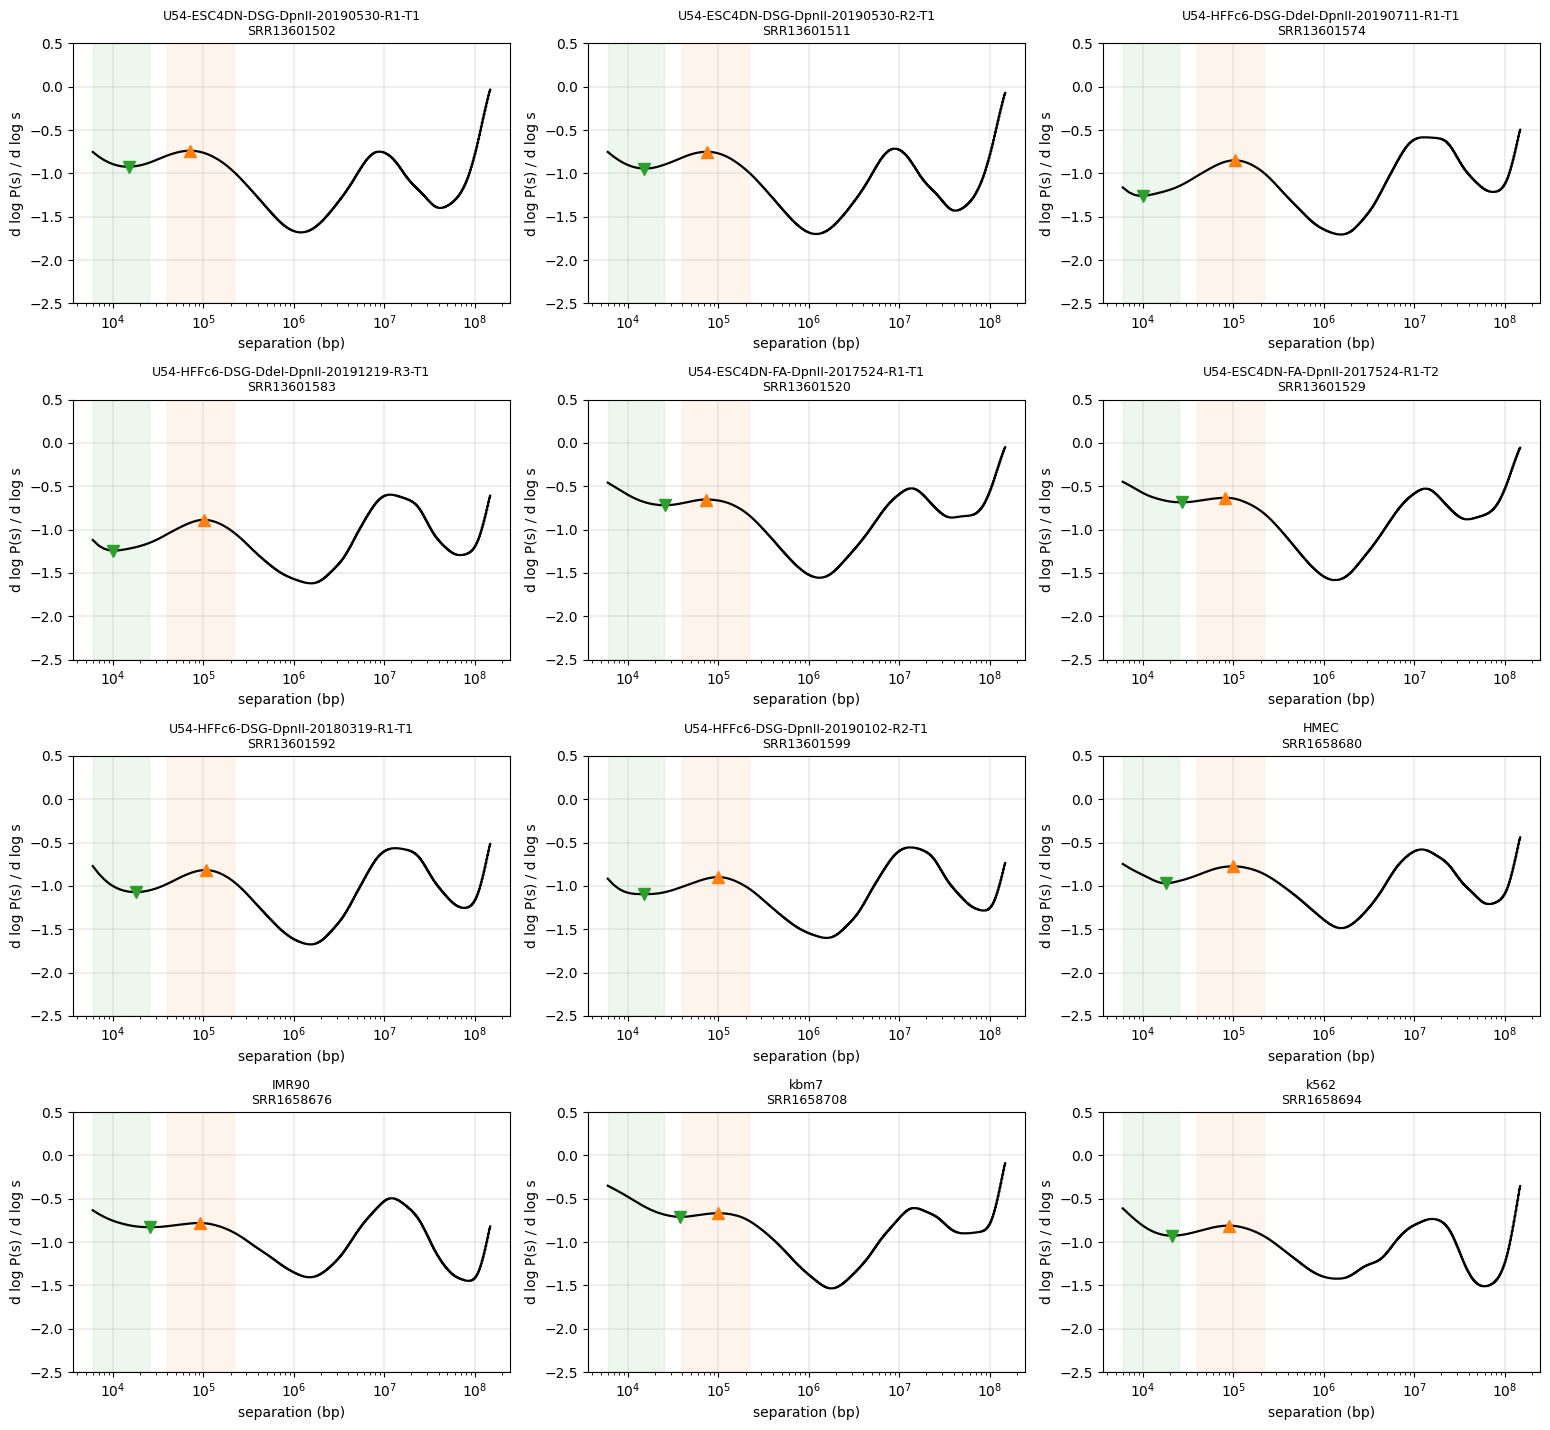

In [13]:
n_cols = 3
n_rows = int(np.ceil(len(DATASETS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 3.6 * n_rows))
axes = axes.flatten()

for ax, (sample_name, srr_name) in zip(axes, DATASETS):
    path = curve_path(srr_name, srr_name)
    dist_bp, expected, slope, num_contacts = load_curve(path)

    ax.semilogx(dist_bp, slope, color="black", lw=1.6)

    row = agg_df[(agg_df["srr_name"] == srr_name) &
                 (agg_df["entity_type"] == "srr_full")].iloc[0]
    ax.plot(row["deep_bp"], row["deep_slope"], "v", color="tab:green", ms=8)
    ax.plot(row["peak_bp"], row["peak_slope"], "^", color="tab:orange", ms=8)

    ax.axvspan(DEEP_MIN_BP, DEEP_MAX_BP, color="tab:green", alpha=0.08)
    ax.axvspan(PEAK_MIN_BP, PEAK_MAX_BP, color="tab:orange", alpha=0.08)
    ax.set_xlabel("separation (bp)")
    ax.set_ylabel("d log P(s) / d log s")
    ax.set_title(f"{sample_name}\n{srr_name}", fontsize=9)
    ax.set_ylim(-2.5, 0.5)
    ax.grid(lw=0.3)

for ax in axes[len(DATASETS):]:
    ax.axis("off")

fig.tight_layout()
plt.show()